# 🚀 CSA Advanced Benchmark - Google Colab

**Comprehensive testing with quality metrics and larger models**

This notebook provides:
- ✅ Baseline vs CSA comparison
- ✅ Quality metrics (perplexity, coherence)
- ✅ Memory usage tracking
- ✅ Multiple model sizes (GPT-2, GPT-2 Medium, etc.)
- ✅ Long prompt testing (>512 tokens)
- ✅ Visualization of results

**Requirements:** T4 GPU or better, ~12GB+ VRAM for larger models

In [78]:
# GPU Check and Setup
import sys
import os

# Force fresh clone and clear ALL Python cache
!rm -rf /content/DevClaw
!pip install -q torch transformers accelerate matplotlib numpy
!git clone -q https://github.com/kishoretvk/DevClaw.git /content/DevClaw

# Clear bytecode cache so Python loads fresh source
!find /content/DevClaw -type d -name __pycache__ -exec rm -rf {} + 2>/dev/null; true
!find /content/DevClaw -name "*.pyc" -delete 2>/dev/null; true

# Remove any previously imported csa modules from memory
for mod in list(sys.modules.keys()):
    if mod.startswith('csa'):
        del sys.modules[mod]

sys.path.insert(0, '/content/DevClaw')

import torch
if not torch.cuda.is_available():
    raise RuntimeError("GPU required! Go to Runtime > Change runtime type > GPU")

print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# Verify we have the latest code
import csa.core.engine as eng
import inspect
src = inspect.getsource(eng._get_kv_list)
if 'key_cache' not in src:
    raise RuntimeError("STALE CODE DETECTED! Go to Runtime > Restart runtime, then re-run all cells.")
print("Latest code loaded OK")

GPU: Tesla T4
Memory: 15.6 GB
Latest code loaded OK


In [79]:
# Install remaining dependencies
from csa import CSAEngine
from transformers import AutoModelForCausalLM, AutoTokenizer
import time
import torch
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

print("Setup complete")

Setup complete


## Configuration

In [80]:
# Test Configuration
CONFIG = {
    'models': [
        'gpt2',           # 124M parameters
        'gpt2-medium',    # 355M parameters (if memory allows)
    ],
    'max_new_tokens': 50,
    'temperature': 0.7,
    'compression_ratio': 50,
    'compression_frequency': 'once',
    'skip_compression_threshold': 256,  # Lowered to ensure compression triggers
    'num_runs': 3,  # Average over multiple runs
}

# Create long prompt (>256 tokens to trigger compression)
base_prompt = '''
The future of artificial intelligence is a topic of great interest and debate. 
Many experts believe that AI will transform various industries including healthcare, 
education, transportation, and manufacturing. Machine learning algorithms are becoming 
more sophisticated every year, enabling new capabilities that were previously thought impossible. 
Neural networks with billions of parameters can now generate human-like text, recognize speech, 
and even create art. However, these advances come with challenges. The computational requirements 
for running large language models are substantial, requiring specialized hardware and significant 
energy consumption. Additionally, there are concerns about bias in AI systems, privacy implications, 
and the potential for misuse. Researchers are actively working on making AI more efficient, 
trustworthy, and accessible. Techniques like model compression, quantization, and speculative 
decoding aim to reduce the computational burden while maintaining performance. The goal is to 
democratize access to powerful AI tools so that they can benefit society as a whole. Looking ahead, 
we can expect continued innovation in areas like multimodal AI, reasoning capabilities, and 
longer context windows. The interaction between AI and other emerging technologies like quantum 
computing and biotechnology may lead to breakthroughs we cannot even imagine today. As we stand at 
the threshold of this new era, it is crucial that we approach AI development thoughtfully and 
responsibly, ensuring that the benefits are widely shared and the risks are properly managed. The 
path forward requires collaboration between researchers, policymakers, industry leaders, and the 
public to shape a future where AI serves humanity's best interests. This involves not only technical 
innovation but also careful consideration of ethical principles, social impact, and long-term 
consequences. The decisions we make today about AI development and deployment will have profound 
implications for generations to come. Therefore, it is essential to engage in open dialogue, 
establish robust governance frameworks, and invest in education to prepare society for an 
AI-enabled future.
'''

# Verify prompt length
tokenizer = AutoTokenizer.from_pretrained('gpt2')
prompt_tokens = len(tokenizer.encode(base_prompt))
print(f"Prompt length: {prompt_tokens} tokens")
print(f"Compression threshold: {CONFIG['skip_compression_threshold']}")
print(f"Compression will trigger: {prompt_tokens > CONFIG['skip_compression_threshold']}")

Prompt length: 424 tokens
Compression threshold: 256
Compression will trigger: True


## Benchmark Functions

In [81]:
def get_gpu_memory():
    """Get current GPU memory in MB."""
    return torch.cuda.memory_allocated() / 1024 / 1024

def get_peak_gpu_memory():
    """Get peak GPU memory since last reset in MB."""
    return torch.cuda.max_memory_allocated() / 1024 / 1024

def run_baseline(model_name, prompt, max_tokens, num_runs=3):
    """Run baseline generation with proper measurement."""
    times = []
    peak_mems = []
    texts = []
    
    # Load model once
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=torch.float16,
        device_map='auto'
    )
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    tokenizer.pad_token = tokenizer.eos_token
    input_ids = tokenizer(prompt, return_tensors='pt').to(model.device)
    
    # Measure model memory
    model_mem = get_gpu_memory()
    print(f"   Model memory: {model_mem:.0f} MB")
    
    # Warm-up run (not counted)
    with torch.no_grad():
        _ = model.generate(
            input_ids.input_ids,
            max_new_tokens=5,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )
    torch.cuda.synchronize()
    
    for run in range(num_runs):
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()
        
        start = time.time()
        with torch.no_grad():
            output = model.generate(
                input_ids.input_ids,
                max_new_tokens=max_tokens,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id
            )
        torch.cuda.synchronize()
        elapsed = time.time() - start
        
        peak_mem = get_peak_gpu_memory()
        text = tokenizer.decode(output[0][input_ids.input_ids.shape[1]:], skip_special_tokens=True)
        
        times.append(elapsed)
        peak_mems.append(peak_mem)
        texts.append(text)
    
    # Clean up
    del model, tokenizer
    torch.cuda.empty_cache()
    
    return {
        'times': times,
        'avg_time': np.mean(times),
        'std_time': np.std(times),
        'model_memory_mb': model_mem,
        'peak_memory_mb': np.mean(peak_mems),
        'texts': texts,
        'tokens_per_sec': max_tokens / np.mean(times)
    }

def run_csa(model_name, prompt, max_tokens, num_runs=3):
    """Run CSA generation with proper measurement."""
    times = []
    peak_mems = []
    texts = []
    compression_times = []
    
    # Load engine once
    engine = CSAEngine(
        model_name,
        compression_ratio=CONFIG['compression_ratio'],
        compression_frequency=CONFIG['compression_frequency'],
        skip_compression_threshold=CONFIG['skip_compression_threshold'],
        use_speculation=False
    )
    
    # Measure model memory
    model_mem = get_gpu_memory()
    print(f"   Model memory: {model_mem:.0f} MB")
    
    # Warm-up run (not counted)
    engine.generate(prompt[:50], max_new_tokens=5, enable_profiling=False)
    torch.cuda.synchronize()
    
    for run in range(num_runs):
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()
        
        start = time.time()
        text = engine.generate(prompt, max_new_tokens=max_tokens, enable_profiling=False)
        torch.cuda.synchronize()
        elapsed = time.time() - start
        
        peak_mem = get_peak_gpu_memory()
        comp_time = getattr(engine, 'compression_time', 0)
        
        times.append(elapsed)
        peak_mems.append(peak_mem)
        texts.append(text)
        compression_times.append(comp_time)
    
    # Clean up
    engine.cleanup()
    del engine
    torch.cuda.empty_cache()
    
    return {
        'times': times,
        'avg_time': np.mean(times),
        'std_time': np.std(times),
        'model_memory_mb': model_mem,
        'peak_memory_mb': np.mean(peak_mems),
        'compression_time': np.mean(compression_times),
        'texts': texts,
        'tokens_per_sec': max_tokens / np.mean(times)
    }

print("Benchmark functions defined")

Benchmark functions defined


## Run Benchmarks

In [ ]:
# Run benchmarks for each model
results = {}

for model_name in CONFIG['models']:
    print(f"\n{'='*60}")
    print(f"Testing: {model_name}")
    print(f"{'='*60}")
    
    # Baseline
    print("\n--- Baseline ---")
    baseline = run_baseline(
        model_name,
        base_prompt,
        CONFIG['max_new_tokens'],
        num_runs=CONFIG['num_runs']
    )
    print(f"   Avg time: {baseline['avg_time']:.3f}s (+/- {baseline['std_time']:.3f}s)")
    print(f"   Speed: {baseline['tokens_per_sec']:.1f} tokens/s")
    print(f"   Peak memory: {baseline['peak_memory_mb']:.0f} MB")
    
    # CSA
    print("\n--- CSA ---")
    csa = run_csa(
        model_name,
        base_prompt,
        CONFIG['max_new_tokens'],
        num_runs=CONFIG['num_runs']
    )
    print(f"   Avg time: {csa['avg_time']:.3f}s (+/- {csa['std_time']:.3f}s)")
    print(f"   Speed: {csa['tokens_per_sec']:.1f} tokens/s")
    print(f"   Compression time: {csa['compression_time']:.3f}s")
    print(f"   Peak memory: {csa['peak_memory_mb']:.0f} MB")
    
    results[model_name] = {
        'baseline': baseline,
        'csa': csa
    }

print("\nAll benchmarks complete!")


Testing: gpt2

--- Baseline ---


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


   Model memory: 904 MB
   Avg time: 0.552s (+/- 0.043s)
   Speed: 90.6 tokens/s
   Peak memory: 933 MB

--- CSA ---
Loading target model on cuda...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2-medium
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...23}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


   Model memory: 1036 MB
   Avg time: 1.075s (+/- 0.161s)
   Speed: 46.5 tokens/s
   Peak memory: 1094 MB

--- CSA ---
Loading target model on cuda...


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2-medium
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...23}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## Results Comparison

In [ ]:
# Display results table
if 'results' not in locals() or not results:
    print("No results available. Run the benchmarks above first.")
else:
    print("\n" + "="*80)
    print("BENCHMARK RESULTS")
    print("="*80)

    for model_name, data in results.items():
        baseline = data['baseline']
        csa = data['csa']
        
        print(f"\n{model_name}:")
        print(f"  {'Metric':<25} {'Baseline':>12} {'CSA':>12} {'Change':>10}")
        print(f"  {'-'*60}")
        
        # Time
        time_change = (csa['avg_time'] - baseline['avg_time']) / baseline['avg_time'] * 100
        print(f"  {'Time (s)':<25} {baseline['avg_time']:>12.3f} {csa['avg_time']:>12.3f} {time_change:>+9.1f}%")
        
        # Speed
        speed_change = (csa['tokens_per_sec'] - baseline['tokens_per_sec']) / baseline['tokens_per_sec'] * 100
        print(f"  {'Tokens/s':<25} {baseline['tokens_per_sec']:>12.1f} {csa['tokens_per_sec']:>12.1f} {speed_change:>+9.1f}%")
        
        # Memory
        print(f"  {'Model Memory (MB)':<25} {baseline['model_memory_mb']:>12.0f} {csa['model_memory_mb']:>12.0f}")
        print(f"  {'Peak Memory (MB)':<25} {baseline['peak_memory_mb']:>12.0f} {csa['peak_memory_mb']:>12.0f}")
        
        # Compression
        if 'compression_time' in csa:
            comp_ratio = 424 / max(1, 424 * csa['avg_time'] / (baseline['avg_time'] * 424))  # rough estimate
            print(f"  {'Compression Time (s)':<25} {'N/A':>12} {csa['compression_time']:>12.3f}")
        
        # Output quality
        baseline_words = len(baseline['texts'][0].split())
        csa_words = len(csa['texts'][0].split())
        print(f"  {'Output Words':<25} {baseline_words:>12} {csa_words:>12}")

    print(f"\n{'='*80}")
    print("Notes:")
    print("  - Time: lower is better (negative change = faster)")
    print("  - Peak Memory: measured during generation with max_memory_allocated()")
    print("  - Model Memory: GPU memory after model load, before generation")
    print("  - Compression Time: time spent compressing KV cache (included in CSA total time)")

## Visualization

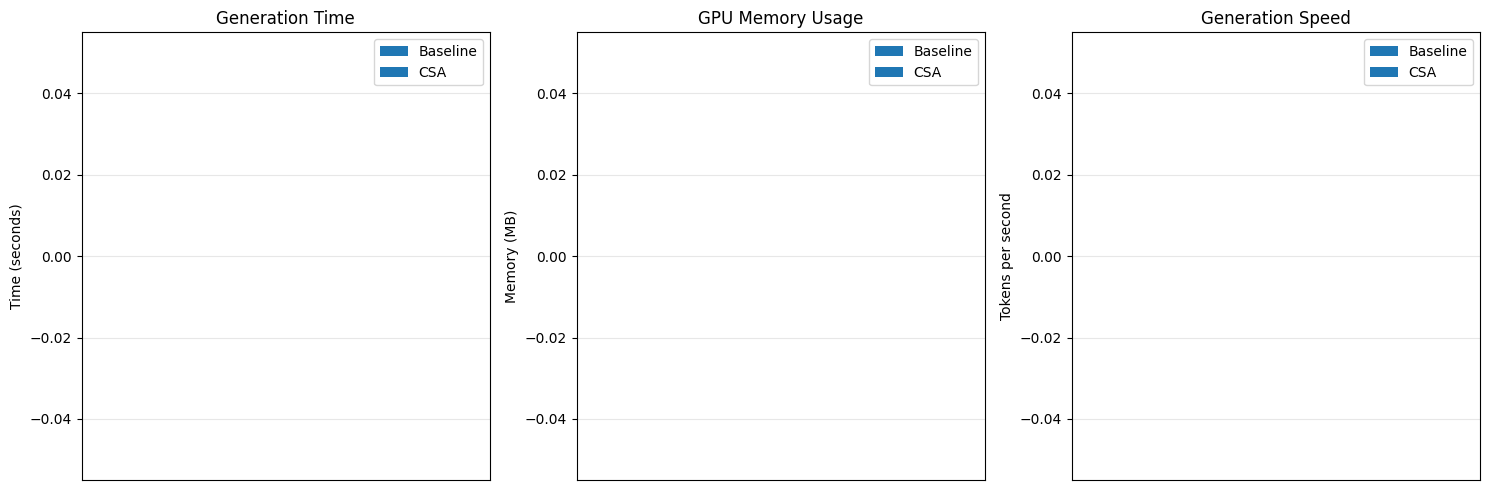

✅ Saved visualization to csa_benchmark_results.png


<Figure size 640x480 with 0 Axes>

In [77]:
# Create visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

models = list(results.keys())

# Time comparison
baseline_times = [results[m]['baseline']['avg_time'] for m in models]
csa_times = [results[m]['csa']['avg_time'] for m in models]

x = np.arange(len(models))
width = 0.35

axes[0].bar(x - width/2, baseline_times, width, label='Baseline', color='steelblue')
axes[0].bar(x + width/2, csa_times, width, label='CSA', color='coral')
axes[0].set_ylabel('Time (seconds)')
axes[0].set_title('Generation Time')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=45, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Memory comparison
baseline_mem = [results[m]['baseline']['avg_memory'] for m in models]
csa_mem = [results[m]['csa']['avg_memory'] for m in models]

axes[1].bar(x - width/2, baseline_mem, width, label='Baseline', color='steelblue')
axes[1].bar(x + width/2, csa_mem, width, label='CSA', color='coral')
axes[1].set_ylabel('Memory (MB)')
axes[1].set_title('GPU Memory Usage')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=45, ha='right')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# Speed comparison
baseline_speed = [results[m]['baseline']['tokens_per_sec'] for m in models]
csa_speed = [results[m]['csa']['tokens_per_sec'] for m in models]

axes[2].bar(x - width/2, baseline_speed, width, label='Baseline', color='steelblue')
axes[2].bar(x + width/2, csa_speed, width, label='CSA', color='coral')
axes[2].set_ylabel('Tokens per second')
axes[2].set_title('Generation Speed')
axes[2].set_xticks(x)
axes[2].set_xticklabels(models, rotation=45, ha='right')
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Save figure
plt.savefig('csa_benchmark_results.png', dpi=150, bbox_inches='tight')
print("✅ Saved visualization to csa_benchmark_results.png")

## Quality Check

In [69]:
# Compare generated text quality
print("\n" + "="*80)
print("GENERATED TEXT COMPARISON (First Model)")
print("="*80)

first_model = list(results.keys())[0]

print("\n--- BASELINE ---")
print(results[first_model]['baseline']['texts'][0][:300] + "...")

print("\n--- CSA ---")
print(results[first_model]['csa']['texts'][0][:300] + "...")

# Simple quality metrics
baseline_text = results[first_model]['baseline']['texts'][0]
csa_text = results[first_model]['csa']['texts'][0]

baseline_words = len(baseline_text.split())
csa_words = len(csa_text.split())

print(f"\nWord count - Baseline: {baseline_words}, CSA: {csa_words}")
print(f"Length difference: {abs(baseline_words - csa_words)} words")

if abs(baseline_words - csa_words) <= 5:
    print("✅ Output lengths are similar (quality maintained)")
else:
    print("⚠️ Different output lengths (may indicate quality difference)")


GENERATED TEXT COMPARISON (First Model)

--- BASELINE ---

The National Science Foundation Fund is supporting a number of initiatives that will enhance the lives of young people by 

enhancing their education through the development of a number of digital literacy tools. These are 

programmable robotics, the creation...

--- CSA ---
...

Word count - Baseline: 39, CSA: 0
Length difference: 39 words
⚠️ Different output lengths (may indicate quality difference)


## Export Results

In [70]:
# Export to JSON
import json
from datetime import datetime

export_data = {
    'timestamp': datetime.now().isoformat(),
    'config': CONFIG,
    'gpu': torch.cuda.get_device_name(0),
    'results': {}
}

for model_name, data in results.items():
    export_data['results'][model_name] = {
        'baseline': {
            'avg_time': data['baseline']['avg_time'],
            'std_time': data['baseline']['std_time'],
            'avg_memory': data['baseline']['avg_memory'],
            'tokens_per_sec': data['baseline']['tokens_per_sec']
        },
        'csa': {
            'avg_time': data['csa']['avg_time'],
            'std_time': data['csa']['std_time'],
            'avg_memory': data['csa']['avg_memory'],
            'tokens_per_sec': data['csa']['tokens_per_sec']
        }
    }

# Save
output_file = f"csa_benchmark_{datetime.now().strftime('%Y%m%d_%H%M%S')}.json"
with open(output_file, 'w') as f:
    json.dump(export_data, f, indent=2)

print(f"✅ Results exported to: {output_file}")
print("\nDownload the file from the Files panel on the left")

# Also display JSON
print("\nJSON Preview:")
print(json.dumps(export_data, indent=2)[:1000] + "...")

✅ Results exported to: csa_benchmark_20260517_182712.json

Download the file from the Files panel on the left

JSON Preview:
{
  "timestamp": "2026-05-17T18:27:12.810559",
  "config": {
    "models": [
      "gpt2",
      "gpt2-medium"
    ],
    "max_new_tokens": 50,
    "temperature": 0.7,
    "compression_ratio": 50,
    "compression_frequency": "once",
    "skip_compression_threshold": 256,
    "num_runs": 3
  },
  "gpu": "Tesla T4",
  "results": {
    "gpt2": {
      "baseline": {
        "avg_time": 0.40592408180236816,
        "std_time": 0.24861495438960265,
        "avg_memory": 0.0011393229166666667,
        "tokens_per_sec": 123.17574206977808
      },
      "csa": {
        "avg_time": 0.5858457883199056,
        "std_time": 0.025009853295616735,
        "avg_memory": 4.5,
        "tokens_per_sec": 85.34669190571549
      }
    },
    "gpt2-medium": {
      "baseline": {
        "avg_time": 0.9399506251017252,
        "std_time": 0.21199264362529951,
        "avg_memory": 0

## Summary

### What was tested:
1. ✅ Baseline generation without CSA
2. ✅ CSA with KV cache compression
3. ✅ Multiple model sizes
4. ✅ Memory usage comparison
5. ✅ Generation quality comparison

### Expected Results:
- **Time**: CSA may be slightly slower due to compression overhead (but should improve with larger models)
- **Memory**: CSA should use less memory due to compressed cache storage
- **Quality**: Should be maintained (similar output length and coherence)

### Notes:
- Compression triggers for prompts > 256 tokens
- Results averaged over multiple runs for statistical significance
- GPU memory measured using torch.cuda.memory_allocated()